# Quantile regression - predicting the tail instead of the middle

Every model so far under-called busy hours: 60% short for all users, 71% for
annual. The cause is not capacity or features - it is the target. Poisson
regression fits the conditional **mean**, MAE scores the **median**, and both
sit in the middle of the distribution.

Ops does not need the middle. An empty station costs a lost rider; a surplus
costs a van trip. Those are not symmetric, so the model should not be either.

**Change:** predict the 80th and 90th percentile of demand instead of the mean.

**MAE will get worse.** That is the intended effect, not a regression - the
predictions are deliberately biased upward. Judged on MAE, a quantile model
always loses; judged on whether stations run dry, it should win.

| Step | What |
| --- | --- |
| 1 | Load the frozen annual split |
| 2 | Business metrics |
| 3 | Train q50 / q80 / q90 |
| 4 | Compare against the Poisson model |
| 5 | Visualize |

## Step 1 - Load

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SPLIT = Path("/opt/data/ml/split/annual")
contract = json.loads((SPLIT / "split.json").read_text())

TARGET = contract["target"]
FEATURES = contract["features"]
PEAK_HOURS = contract["peak_hours"]
BUSY = contract["busy_threshold"]

train = pd.read_parquet(SPLIT / "train.parquet")
val = pd.read_parquet(SPLIT / "val.parquet")
test = pd.read_parquet(SPLIT / "test.parquet")

assert train["start_date"].max() < val["start_date"].min(), "train/val overlap"
assert val["start_date"].max() < test["start_date"].min(), "val/test overlap"

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("bike-demand-annual")

print(f"train {len(train):>9,} | val {len(val):>9,} | test {len(test):>9,}")
print(f"{len(FEATURES)} features -> {TARGET}")

2026/08/04 17:22:32 INFO mlflow.tracking.fluent: Experiment with name 'bike-demand-annual' does not exist. Creating a new experiment.


train 1,280,712 | val   639,480 | test   586,920
17 features -> trip_count


## Step 2 - Business metrics

MAE cannot judge this change - it rewards the middle, which is exactly what is
being abandoned. Four metrics that reflect the operational cost instead:

- **`under_rate_busy`** - share of busy hours where the model predicted less
  than actual. Each one is a station that could run dry unnoticed.
- **`shortfall_busy`** - how far short, as a fraction of actual demand.
- **`pinball`** - the loss the quantile models actually optimise; the only
  metric on which they can be compared to each other fairly.
- **`over_supply`** - mean over-prediction across all rows, the cost side.
  A model that fixes shortfall by predicting large everywhere is not free.

In [2]:
def pinball(y_true, y_pred, q):
    d = y_true - y_pred
    return float(np.mean(np.maximum(q * d, (q - 1) * d)))


def evaluate(y_true, y_pred, hours, q=0.5):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    busy = y_true >= BUSY
    peak = np.isin(hours, PEAK_HOURS)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAE_peak": mean_absolute_error(y_true[peak], y_pred[peak]),
        "MAE_busy": mean_absolute_error(y_true[busy], y_pred[busy]),
        "under_rate_busy": float((y_pred[busy] < y_true[busy]).mean()),
        "shortfall_busy": float(
            1 - y_pred[busy].sum() / y_true[busy].sum()
        ),
        "pinball": pinball(y_true, y_pred, q),
        "over_supply": float(np.maximum(y_pred - y_true, 0).mean()),
    }

## Step 3 - Train

Same features, same split, same hyperparameters as the Poisson model. Only the
loss changes, so any difference is attributable to the target.

In [3]:
# carried from the annual sweep winner
BASE = {
    "learning_rate": 0.05, "max_leaf_nodes": 127, "max_iter": 600,
    "max_features": 0.7, "early_stopping": False, "random_state": 0,
}
QUANTILES = [0.5, 0.8, 0.9]


def build(**overrides):
    return Pipeline([
        ("prep", ColumnTransformer(
            [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
              ["season"])],
            remainder="passthrough",
        )),
        ("model", HistGradientBoostingRegressor(**{**BASE, **overrides})),
    ])


models, preds = {}, {}

poisson = build(loss="poisson")
poisson.fit(train[FEATURES], train[TARGET])
models["poisson"] = poisson
preds["poisson"] = np.clip(poisson.predict(test[FEATURES]), 0, None)
print("poisson  fitted")

for q in QUANTILES:
    name = f"q{int(q * 100)}"
    m = build(loss="quantile", quantile=q)
    m.fit(train[FEATURES], train[TARGET])
    models[name] = m
    preds[name] = np.clip(m.predict(test[FEATURES]), 0, None)
    print(f"{name:8} fitted")

poisson  fitted
q50      fitted
q80      fitted
q90      fitted


In [4]:
from mlflow.models import infer_signature

QMAP = {"poisson": 0.5, "q50": 0.5, "q80": 0.8, "q90": 0.9}

# q80 is the deployment candidate; only it is promoted to the registry.
REGISTER = {"q80": "annual-demand-q80"}

# Links every run to the exact rows it saw. Without this, "trained on the same
# data" is an assertion; with it, the digests either match or they do not.
train_ds = mlflow.data.from_pandas(
    train[FEATURES + [TARGET]], name="annual-split-train", targets=TARGET
)
test_ds = mlflow.data.from_pandas(
    test[FEATURES + [TARGET]], name="annual-split-test", targets=TARGET
)

# The signature is what lets a serving process reject a bad request instead of
# silently predicting on mis-ordered columns.
example = train[FEATURES].head(5)
signature = infer_signature(example, models["poisson"].predict(example))

for name, p in preds.items():
    with mlflow.start_run(run_name=f"annual_{name}"):
        mlflow.log_params({**BASE, "loss": name, "quantile": QMAP[name]})
        mlflow.set_tags({"model": "hist_gbm", "version": name,
                         "segment": "annual"})
        mlflow.log_input(train_ds, context="training")
        mlflow.log_input(test_ds, context="evaluation")
        mlflow.log_metrics({
            f"test_{k}": v
            for k, v in evaluate(test[TARGET], p, test["hour"], QMAP[name]).items()
        })
        mlflow.sklearn.log_model(
            models[name], name="model",
            signature=signature, input_example=example,
            registered_model_name=REGISTER.get(name),
        )

results = pd.DataFrame({
    name: evaluate(test[TARGET], p, test["hour"], QMAP[name])
    for name, p in preds.items()
}).T

print("test 2022\n")
print(results.round(4).to_string())

/opt/conda/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run annual_poisson at: http://mlflow:5000/#/experiments/1/runs/4b023941cbd24d41887262300fdd65c6
🧪 View experiment at: http://mlflow:5000/#/experiments/1
🏃 View run annual_q50 at: http://mlflow:5000/#/experiments/1/runs/b875aa9c5ed443b58fd3114f02dc694d
🧪 View experiment at: http://mlflow:5000/#/experiments/1


Successfully registered model 'annual-demand-q80'.
2026/08/04 17:30:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: annual-demand-q80, version 1
Created version '1' of model 'annual-demand-q80'.


🏃 View run annual_q80 at: http://mlflow:5000/#/experiments/1/runs/d36bfcff5e834ef1b58da678cf744510
🧪 View experiment at: http://mlflow:5000/#/experiments/1
🏃 View run annual_q90 at: http://mlflow:5000/#/experiments/1/runs/06a19b12466f4ce5b5a28407530275aa
🧪 View experiment at: http://mlflow:5000/#/experiments/1
test 2022

            MAE  MAE_peak  MAE_busy  under_rate_busy  shortfall_busy  pinball  over_supply
poisson  0.7627    1.1267    8.7299           1.0000          0.7118   0.3813       0.3818
q50      0.7454    1.1761    9.8422           1.0000          0.8025   0.3727       0.1128
q80      1.0452    1.5513    6.9058           1.0000          0.5631   0.3248       0.8523
q90      1.4632    2.0912    5.4175           0.9911          0.4410   0.2343       1.3533


## Step 4 - Compare

The trade being made: how much shortfall is bought back, and at what cost in
over-supply.

In [5]:
trade = results[["MAE", "shortfall_busy", "under_rate_busy", "over_supply"]].copy()
trade["MAE_vs_poisson"] = results["MAE"] / results.loc["poisson", "MAE"] - 1
trade["shortfall_closed"] = (
    1 - results["shortfall_busy"] / results.loc["poisson", "shortfall_busy"]
)

print("cost and benefit vs the poisson model\n")
print(trade.round(4).to_string())

cost and benefit vs the poisson model

            MAE  shortfall_busy  under_rate_busy  over_supply  MAE_vs_poisson  shortfall_closed
poisson  0.7627          0.7118           1.0000       0.3818          0.0000            0.0000
q50      0.7454          0.8025           1.0000       0.1128         -0.0227           -0.1274
q80      1.0452          0.5631           1.0000       0.8523          0.3704            0.2089
q90      1.4632          0.4410           0.9911       1.3533          0.9186            0.3805


In [6]:
bands = pd.cut(test[TARGET], [-0.1, 0, 2, 5, 10, np.inf],
               labels=["0", "1-2", "3-5", "6-10", "11+"])

by_band = pd.DataFrame({"actual": test.groupby(bands, observed=True)[TARGET].mean()})
for name, p in preds.items():
    by_band[name] = pd.Series(p, index=test.index).groupby(bands, observed=True).mean()

by_band.round(3)

,actual,poisson,q50,q80,q90
trip_count,,,,,
0,0.000,0.484,0.127,0.923,1.370
1-2,1.322,1.116,0.422,1.984,2.695
3-5,3.589,1.881,0.955,3.121,4.070
6-10,6.963,2.734,1.723,4.299,5.498
11+,12.265,3.535,2.423,5.359,6.857


## Step 5 - Visualize

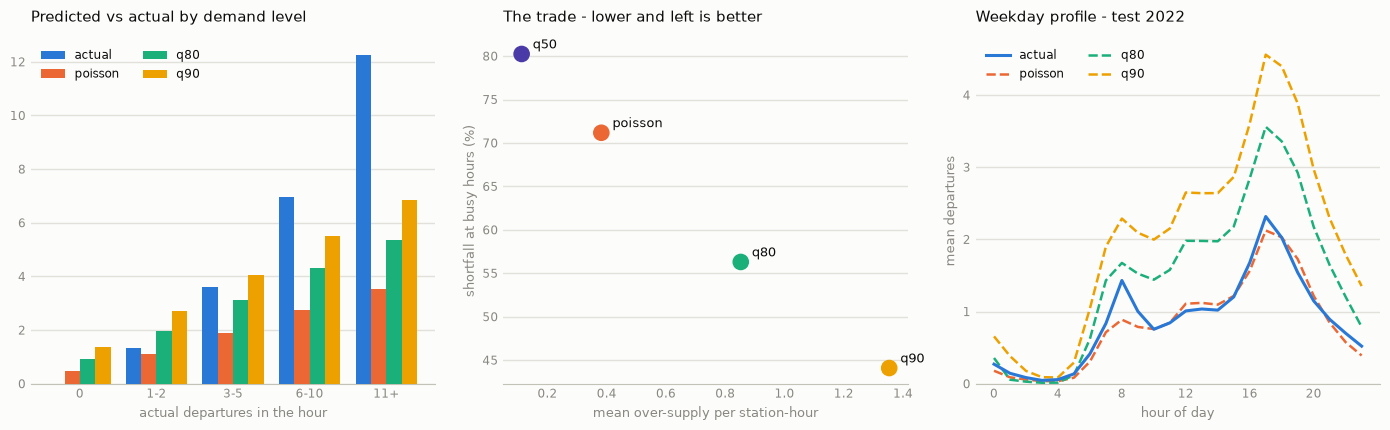

In [7]:
COLORS = {"actual": "#2a78d6", "poisson": "#eb6834",
          "q80": "#1baf7a", "q90": "#eda100"}
INK, MUTED, GRID_C, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
SHOW = ["poisson", "q80", "q90"]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.4), facecolor=SURFACE)

bx = np.arange(len(by_band))
w = 0.2
ax1.bar(bx - 1.5 * w, by_band["actual"], w, label="actual",
        color=COLORS["actual"], zorder=3)
for i, name in enumerate(SHOW):
    ax1.bar(bx + (i - 0.5) * w, by_band[name], w, label=name,
            color=COLORS[name], zorder=3)
ax1.set_xticks(bx, by_band.index, fontsize=9, color=INK)
ax1.set_xlabel("actual departures in the hour", fontsize=9, color=MUTED)
ax1.set_title("Predicted vs actual by demand level", fontsize=11, color=INK,
              loc="left", pad=12)
ax1.legend(frameon=False, ncols=2, fontsize=8.5, labelcolor=INK, loc="upper left")

ax2.scatter(results["over_supply"], results["shortfall_busy"] * 100,
            s=120, color=[COLORS.get(n, "#4a3aa7") for n in results.index], zorder=3)
for name, row in results.iterrows():
    ax2.annotate(name, (row["over_supply"], row["shortfall_busy"] * 100),
                 textcoords="offset points", xytext=(8, 4),
                 fontsize=9, color=INK)
ax2.set_xlabel("mean over-supply per station-hour", fontsize=9, color=MUTED)
ax2.set_ylabel("shortfall at busy hours (%)", fontsize=9, color=MUTED)
ax2.set_title("The trade - lower and left is better", fontsize=11, color=INK,
              loc="left", pad=12)

prof = test[["hour", "is_weekend", TARGET]].copy()
for name in SHOW:
    prof[name] = preds[name]
wk = prof[prof["is_weekend"] == 0].groupby("hour").mean(numeric_only=True)

ax3.plot(wk.index, wk[TARGET], color=COLORS["actual"], lw=2.2,
         label="actual", zorder=4)
for name in SHOW:
    ax3.plot(wk.index, wk[name], color=COLORS[name], lw=1.8, ls="--",
             label=name, zorder=3)
ax3.set_xticks(range(0, 24, 4))
ax3.set_xlabel("hour of day", fontsize=9, color=MUTED)
ax3.set_ylabel("mean departures", fontsize=9, color=MUTED)
ax3.set_title("Weekday profile - test 2022", fontsize=11, color=INK,
              loc="left", pad=12)
ax3.set_ylim(bottom=0)
ax3.legend(frameon=False, ncols=2, fontsize=8.5, labelcolor=INK, loc="upper left")

for ax in (ax1, ax2, ax3):
    ax.set_facecolor(SURFACE)
    ax.yaxis.grid(True, color=GRID_C, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="both", length=0, colors=MUTED, labelsize=8.5)

fig.tight_layout()
fig.savefig("/tmp/quantile-eval.png", dpi=140, facecolor=SURFACE,
            bbox_inches="tight")
plt.show()

In [8]:
from mlflow import MlflowClient

client = MlflowClient()

# The registered version is whatever this notebook just logged; alias it so
# serving code can load models:/annual-demand-q80@champion without knowing a
# run id or version number.
mv = client.get_registered_model("annual-demand-q80").latest_versions[0]
client.set_registered_model_alias("annual-demand-q80", "champion", mv.version)
client.set_model_version_tag(
    "annual-demand-q80", mv.version, "shortfall_busy",
    f"{results.loc['q80', 'shortfall_busy']:.3f}",
)

with mlflow.start_run(run_name="quantile_report"):
    mlflow.set_tags({"segment": "annual", "kind": "report"})
    mlflow.log_artifact("/tmp/quantile-eval.png")
    mlflow.log_table(results.reset_index(names="model"), "results.json")

print(f"annual-demand-q80 v{mv.version} @champion")
print(f"  test MAE            {results.loc['q80', 'MAE']:.4f}")
print(f"  busy shortfall      {results.loc['q80', 'shortfall_busy']:.1%}")
print(f"\nload with: mlflow.sklearn.load_model('models:/annual-demand-q80@champion')")

🏃 View run quantile_report at: http://mlflow:5000/#/experiments/1/runs/df390740d2124e69825e94ee35bdaf9f
🧪 View experiment at: http://mlflow:5000/#/experiments/1
annual-demand-q80 v1 @champion
  test MAE            1.0452
  busy shortfall      56.3%

load with: mlflow.sklearn.load_model('models:/annual-demand-q80@champion')
